In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import calendar as cld
import matplotlib.pyplot as plt
import matplotlib.colors
colors_land = plt.cm.terrain(np.linspace(0.25, 1, 256))
import proplot as pplt # New plot library (https://proplot.readthedocs.io/en/latest/)
pplt.rc['savefig.dpi'] = 300 # 1200 is too big! #https://proplot.readthedocs.io/en/latest/basics.html#Creating-figures
from scipy.stats import chi2
from numba import njit,prange
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 0.05  # previous pdf hatch linewidth
from matplotlib.dates import DateFormatter

from scipy.stats import linregress

In [3]:
normal_format = {'gridlinewidth':0.1, 'gridcolor':'gray8', 'gridalpha':0.5, 'coast':True,'borders':True ,'reso':'hi', 'labels':True, 'lonlines':2, 'latlines':2, 'abc':False, 'latlim':[43.,48.5],'lonlim':[4.,16.]}
multiplot_format = {'gridlinewidth':0.1, 'gridcolor':'gray8', 'gridalpha':0.5, 'coast':True,'borders':True ,'reso':'hi', 'labels':False, 'lonlines':2, 'latlines':2, 'abc':False, 'latlim':[43.,48.5],'lonlim':[4.,16.]}

imin = 32 ; imax = -30
jmin = 20 ; jmax = -15
ds = xr.open_dataset('/bettik/beaumetj/MARout/MAR-ERA-20C/MARgrid_EUf.nc')
lon = ds.LON[jmin:jmax,imin:imax]
lat = ds.LAT[jmin:jmax,imin:imax]
H = np.array(ds.SH[jmin:jmax,imin:imax])

In [4]:
wp_meanseason_meanT = np.load('/bettik/castelli/data/saved_data_MAR_ECEarth3/wp_meanseason_meanT.npy')[:,:,jmin:jmax,imin:imax]

wp_meanseason_meanT_hist = wp_meanseason_meanT[:54,:,:,:]
wp_meanseason_meanT_fut = wp_meanseason_meanT[55:,:,:,:]

origin_T_hist=np.full(wp_meanseason_meanT_hist.shape[1:4],np.nan)
slope_T_hist=np.full(wp_meanseason_meanT_hist.shape[1:4],np.nan)
pvalue_T_hist=np.full(wp_meanseason_meanT_hist.shape[1:4],np.nan)

origin_T_fut=np.full(wp_meanseason_meanT_fut.shape[1:4],np.nan)
slope_T_fut=np.full(wp_meanseason_meanT_fut.shape[1:4],np.nan)
pvalue_T_fut=np.full(wp_meanseason_meanT_fut.shape[1:4],np.nan)

for i in range(wp_meanseason_meanT.shape[3]):
    # print(str(lon)+'/'+str(les_season_maxT.shape[3]),end=' ')
    for j in range(wp_meanseason_meanT.shape[2]):
        for season in range(4):
            linregress_T_hist = linregress(np.arange(wp_meanseason_meanT_hist.shape[0]), wp_meanseason_meanT_hist[:,season,j,i])
            origin_T_hist[season][j][i] = linregress_T_hist.intercept
            slope_T_hist[season][j][i] = linregress_T_hist.slope
            pvalue_T_hist[season][j][i] = linregress_T_hist.pvalue
            
            linregress_T_fut = linregress(np.arange(wp_meanseason_meanT_fut.shape[0]), wp_meanseason_meanT_fut[:,season,j,i])
            origin_T_fut[season][j][i] = linregress_T_fut.intercept
            slope_T_fut[season][j][i] = linregress_T_fut.slope
            pvalue_T_fut[season][j][i] = linregress_T_fut.pvalue

In [5]:
def detect_alps(H):
    nlat,nlon = np.shape(H)
    mask = np.bool8(np.zeros((nlat,nlon)))
    r = 4
    for j in range(r,nlat-r):
        for i in range(r,nlon-r):
            mask[j,i] = np.logical_and(H[j,i]>360 ,np.any(H[j-r:j+r,i-r:i+r]>1300))
            # mask[j,i] = np.std(H[j-r:j+r,i-r:i+r])>200
    return mask
alps = detect_alps(H)
alps[lon<4.8] = False
alps[np.logical_and(lon>10,lat<45.2)] = False

north_alps = np.copy(alps)
north_alps[lon>8.6] = False
north_alps[lat<45] = False
#north_alps[lat>46.5] = False

south_alps = np.copy(alps)
south_alps[lat>45] = False

east_alps = np.copy(alps)
east_alps[lon<8.6] = False

(0.0, 3500.0)

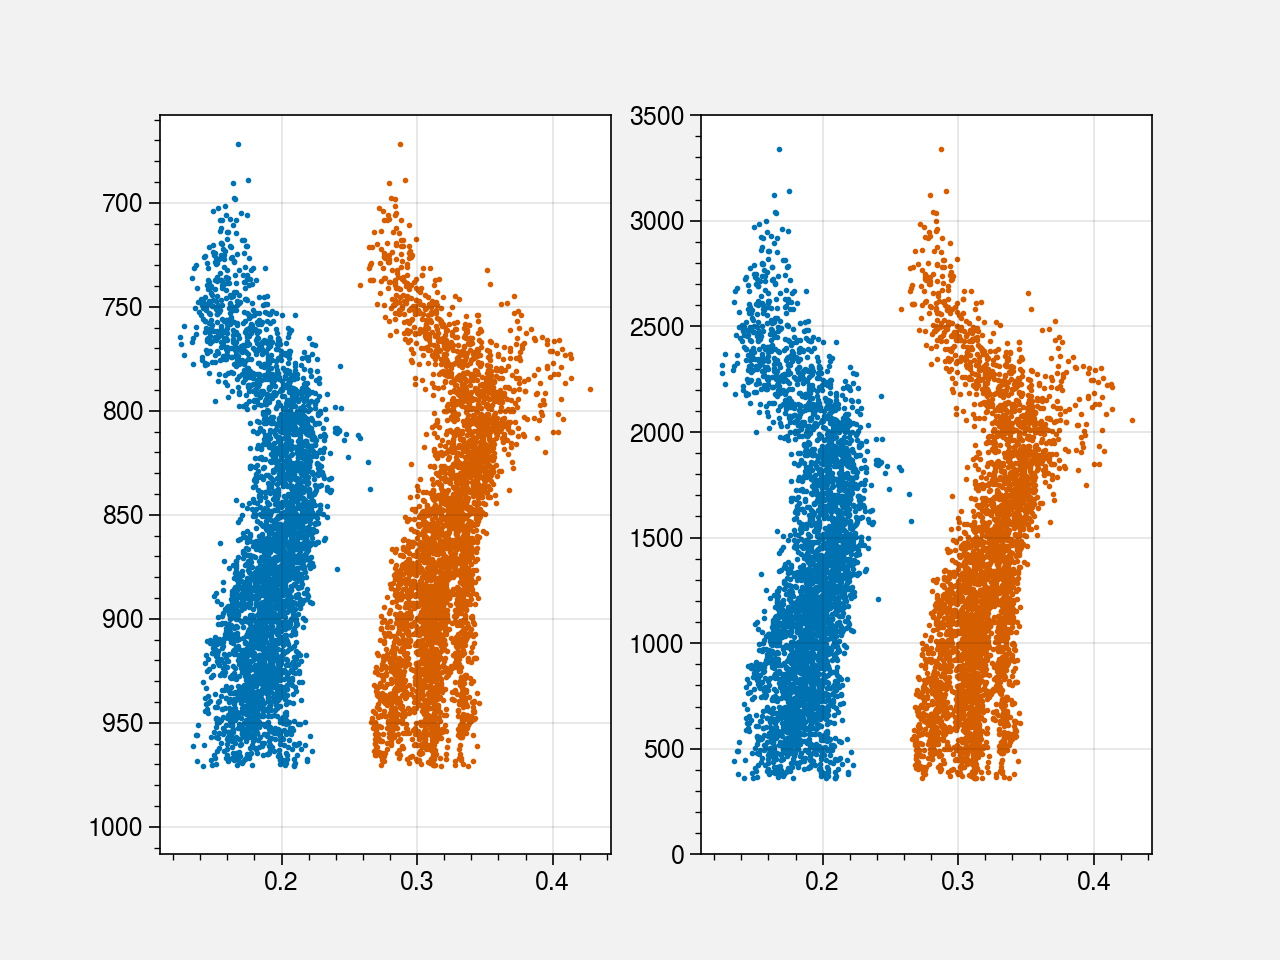

In [6]:
# Ajout de coordonnée verticale pression dans le cas de l'atmosphère standard OACI
def z_to_p(H):
    p0 = 1013.25 # hPa
    gamma = 6.5*10**(-3) # K/m
    T0 = 288.5 # K
    g = 9.81 # m.s^-2
    R = 287 # J/kg/K
    pressure = p0*(1-gamma/T0*H)**(g/gamma/R)
    return pressure

# compare with pressure coordinate

f, axs = plt.subplots(ncols=2)
leg = ['1961-2014','2015-2100']

ax = axs[0]
blue_dot = ax.scatter(10*np.ma.masked_array(slope_T_hist[1], mask=np.invert(alps)),z_to_p(ds.SH[jmin:jmax,imin:imax]),s=2)
orange_dot = ax.scatter(10*np.ma.masked_array(slope_T_fut[1], mask=np.invert(alps)),z_to_p(ds.SH[jmin:jmax,imin:imax]),s=2)
ax.set_ylim((1013.25,657.85))

ax = axs[1]
blue_dot = ax.scatter(10*np.ma.masked_array(slope_T_hist[1], mask=np.invert(alps)),ds.SH[jmin:jmax,imin:imax],s=2)
orange_dot = ax.scatter(10*np.ma.masked_array(slope_T_fut[1], mask=np.invert(alps)),ds.SH[jmin:jmax,imin:imax],s=2)
ax.set_ylim((0,3500))

In [7]:
wp_meanseason_meanSP = np.load('/bettik/castelli/data/saved_data_MAR_ECEarth3/wp_meanseason_meanSP.npy')[:,:,jmin:jmax,imin:imax]

wp_meanseason_meanSP.shape

(140, 4, 91, 139)

In [8]:
wp_meanseason_meanSP_hist = wp_meanseason_meanSP[:54,:,:,:]
wp_meanseason_meanSP_fut = wp_meanseason_meanSP[55:,:,:,:]

wp_meanseason_meanSP_meanhist = wp_meanseason_meanSP_hist.mean(axis=0)
wp_meanseason_meanSP_meanfut = wp_meanseason_meanSP_fut.mean(axis=0)


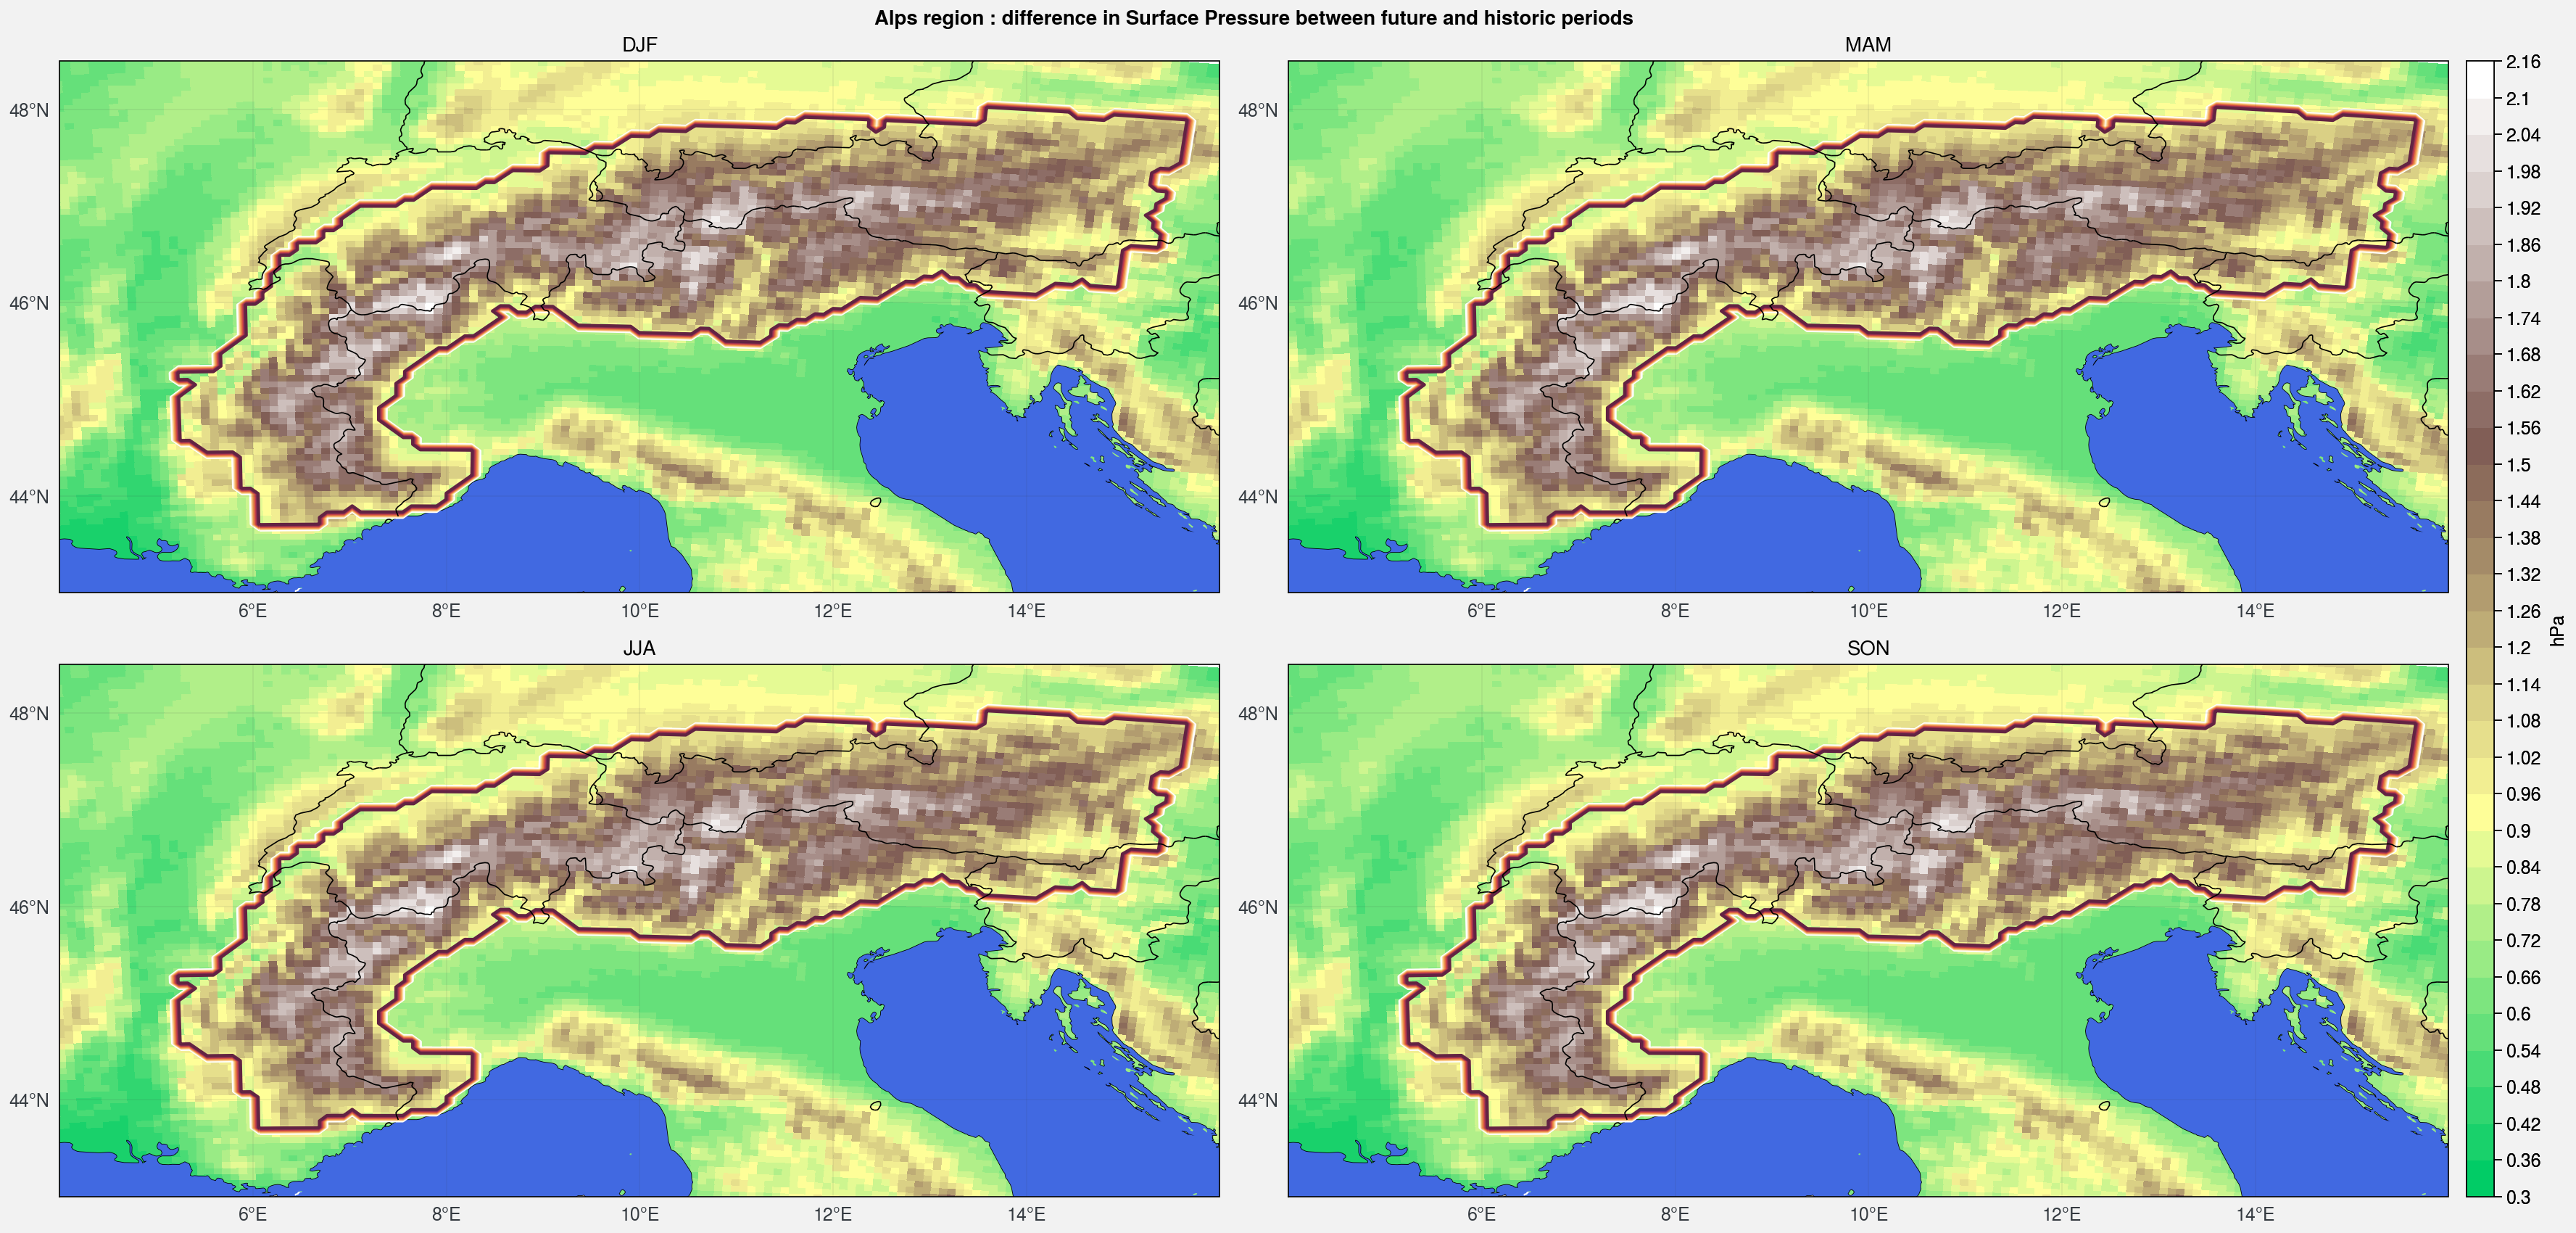

In [9]:
f, axs = pplt.subplots(proj='cyl', nrows = 2, ncols = 2, axwidth=8)

m=axs[0].pcolormesh(lon, lat, wp_meanseason_meanSP_meanfut[0]-wp_meanseason_meanSP_meanhist[0], levels=34,cmap=colors_land)
f.colorbar(m,label= 'hPa')
axs[0].contour(lon, lat,alps)
axs[0].format(**normal_format,title='DJF')
axs[0].format(ocean=True,oceancolor='royalblue',reso='hi')#, latlim=[40.,51.],lonlim=[0.,20.])

m=axs[1].pcolormesh(lon, lat, wp_meanseason_meanSP_meanfut[0]-wp_meanseason_meanSP_meanhist[0], levels=34,cmap=colors_land)
axs[1].contour(lon, lat,alps)
axs[1].format(**normal_format,title='MAM')
axs[1].format(ocean=True,oceancolor='royalblue',reso='hi')#, latlim=[40.,51.],lonlim=[0.,20.])

m=axs[2].pcolormesh(lon, lat, wp_meanseason_meanSP_meanfut[0]-wp_meanseason_meanSP_meanhist[0], levels=34,cmap=colors_land)
axs[2].contour(lon, lat,alps)
axs[2].format(**normal_format,title='JJA')
axs[2].format(ocean=True,oceancolor='royalblue',reso='hi')#, latlim=[40.,51.],lonlim=[0.,20.])

m=axs[3].pcolormesh(lon, lat, wp_meanseason_meanSP_meanfut[0]-wp_meanseason_meanSP_meanhist[0], levels=34,cmap=colors_land)
axs[3].contour(lon, lat,alps)
axs[3].format(**normal_format,title='SON')
axs[3].format(ocean=True,oceancolor='royalblue',reso='hi')#, latlim=[40.,51.],lonlim=[0.,20.])

axs.format(suptitle='Alps region : difference in Surface Pressure between future and historic periods')

Text(0.5, 1.0, 'Altitude')

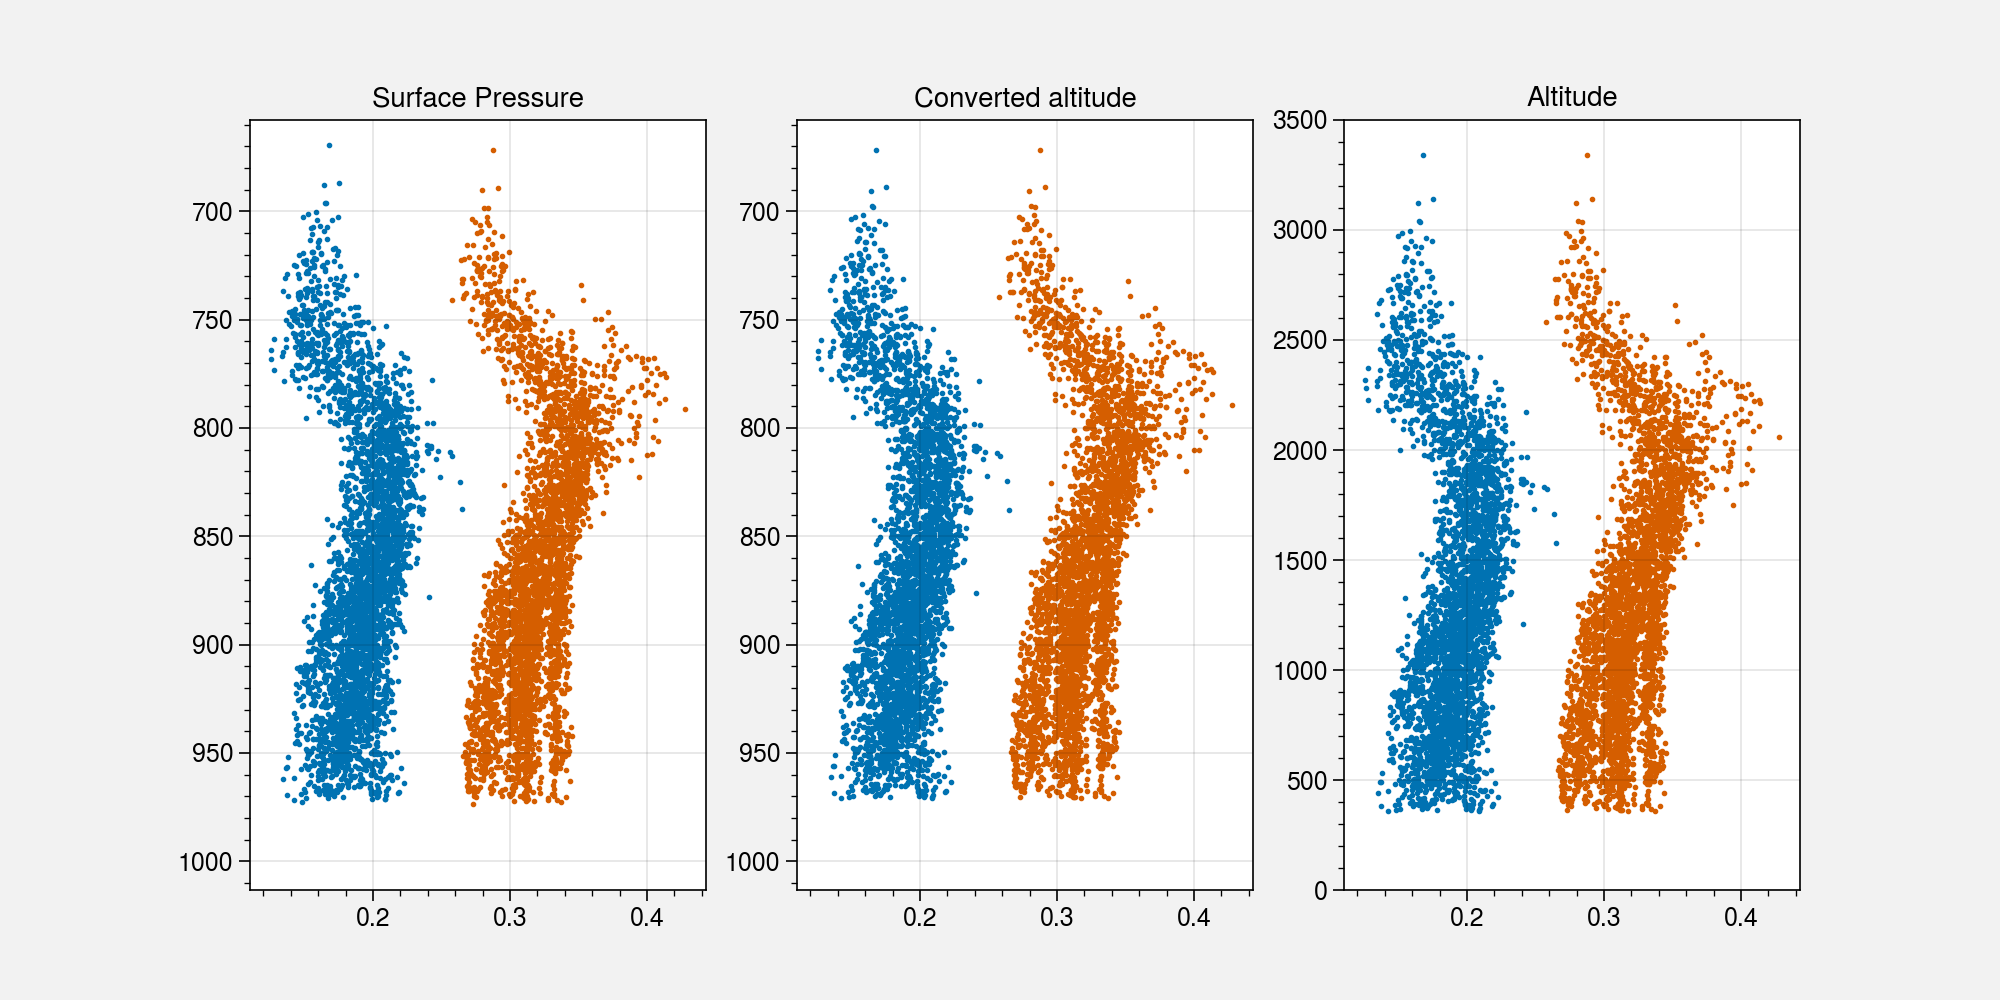

In [10]:
f, axs = plt.subplots(ncols=3, figsize=(10,5))
leg = ['1961-2014','2015-2100']


ax = axs[0]
blue_dot = ax.scatter(10*np.ma.masked_array(slope_T_hist[1], mask=np.invert(alps)),wp_meanseason_meanSP_meanhist[1],s=2)
orange_dot = ax.scatter(10*np.ma.masked_array(slope_T_fut[1], mask=np.invert(alps)),wp_meanseason_meanSP_meanfut[1],s=2)
ax.set_ylim((1013.25,657.85))
ax.set_title('Surface Pressure')

ax = axs[1]
blue_dot = ax.scatter(10*np.ma.masked_array(slope_T_hist[1], mask=np.invert(alps)),z_to_p(ds.SH[jmin:jmax,imin:imax]),s=2)
orange_dot = ax.scatter(10*np.ma.masked_array(slope_T_fut[1], mask=np.invert(alps)),z_to_p(ds.SH[jmin:jmax,imin:imax]),s=2)
ax.set_ylim((1013.25,657.85))
ax.set_title('Converted altitude')

ax = axs[2]
blue_dot = ax.scatter(10*np.ma.masked_array(slope_T_hist[1], mask=np.invert(alps)),ds.SH[jmin:jmax,imin:imax],s=2)
orange_dot = ax.scatter(10*np.ma.masked_array(slope_T_fut[1], mask=np.invert(alps)),ds.SH[jmin:jmax,imin:imax],s=2)
ax.set_ylim((0,3500))
ax.set_title('Altitude')

(1013.25, 657.85)

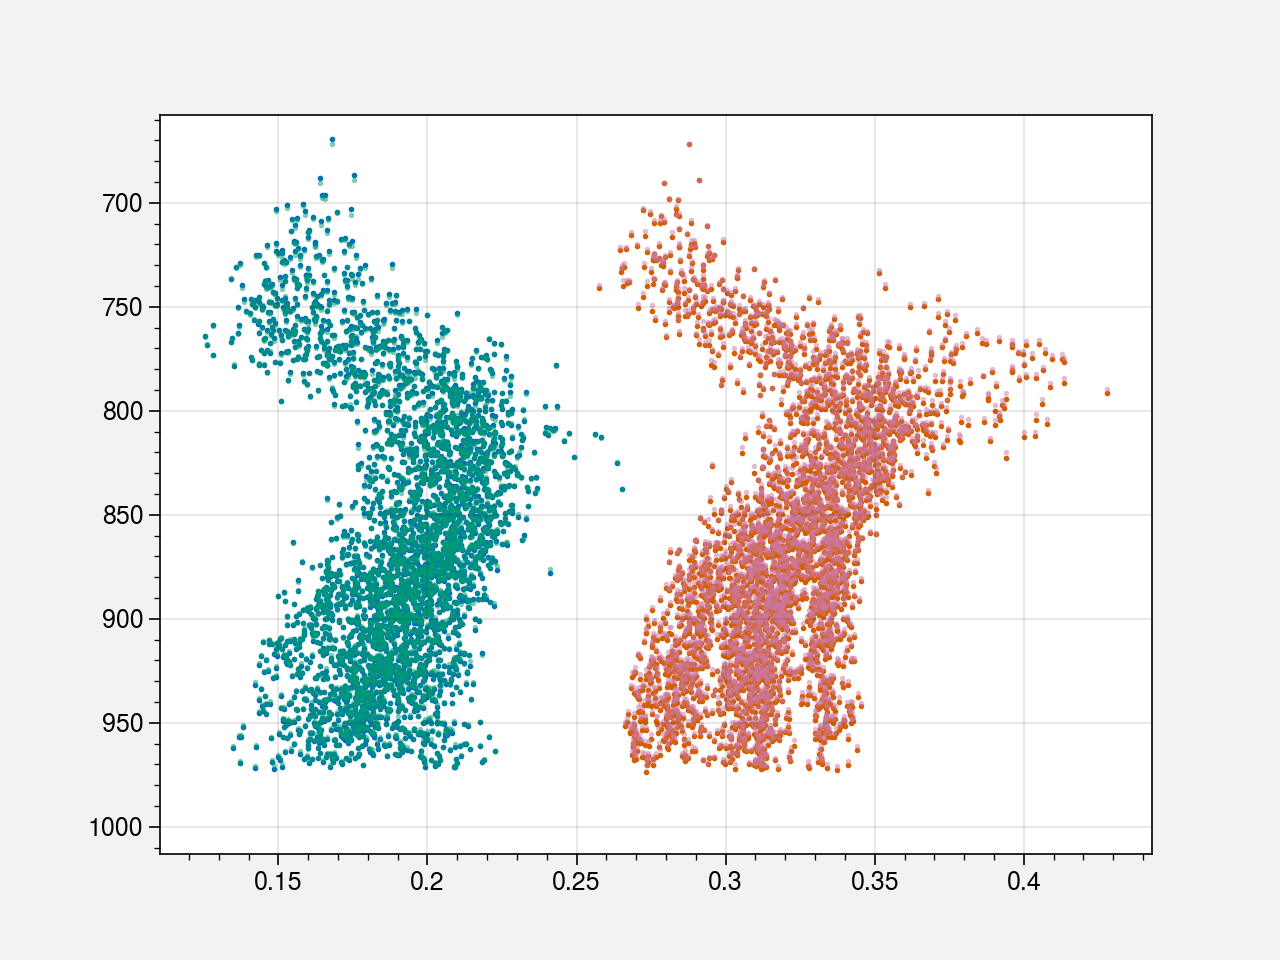

In [11]:
f,ax = plt.subplots()

blue_dot = ax.scatter(10*np.ma.masked_array(slope_T_hist[1], mask=np.invert(alps)),wp_meanseason_meanSP_meanhist[1],s=2)
orange_dot = ax.scatter(10*np.ma.masked_array(slope_T_fut[1], mask=np.invert(alps)),wp_meanseason_meanSP_meanfut[1],s=2)

green_dot = ax.scatter(10*np.ma.masked_array(slope_T_hist[1], mask=np.invert(alps)),z_to_p(ds.SH[jmin:jmax,imin:imax]),s=2,alpha=0.4)
what_dot = ax.scatter(10*np.ma.masked_array(slope_T_fut[1], mask=np.invert(alps)),z_to_p(ds.SH[jmin:jmax,imin:imax]),s=2,alpha=0.4)
ax.set_ylim((1013.25,657.85))